# Stochastic Series Expansion for the Spin-1/2 Heisenberg Chain

## Context and Motivation
The Stochastic Series Expansion (SSE) is a highly efficient Quantum Monte Carlo (QMC) method designed to study the thermodynamic properties of quantum lattice models at finite temperatures. Unlike methods based on the Suzuki-Trotter decomposition, SSE avoids systematic time-discretization errors by directly sampling the Taylor expansion of the partition function. This approach is essential for investigating many-body quantum systems where the Hilbert space grows exponentially, making exact diagonalization computationally impossible for large system sizes. By mapping the quantum problem onto a high-dimensional classical configuration space of operator sequences, SSE provides a powerful tool for obtaining high-precision results for magnetic and thermal observables.

## Theoretical Background
The core of this project is the study of the one-dimensional spin-1/2 Heisenberg model. The system is described by the following Hamiltonian:

$$H = J \sum_{i=1}^{L} \vec{S}_{i} \cdot \vec{S}_{i+1}$$

- where $L$ is the length of the chain and periodic boundary conditions are assumed, such that $L+1 \equiv 1$. Understanding this project requires familiarity with:
- **The Heisenberg Model:** A fundamental paradigm for describing exchange interactions between neighboring spins in magnetic materials.
- **Exchange Coupling ($J$):** The behavior of the system changes drastically depending on the sign of $J$, leading to either an Anti-ferromagnetic ($J=1$) or a Ferromagnetic ($J=-1$) ground state.
- **Magnetic Susceptibility ($\chi$):** A thermodynamic response function that characterizes how the magnetization of the system reacts to an external magnetic field, which we will compute as a function of temperature $T$.
- **Statistical Mechanics of SSE:** The representation of the partition function $Z = \text{Tr}(e^{-\beta H})$ as a summation over operator strings and spin states.

## Objectives of the Project
The primary goal is to develop a robust numerical tool to simulate the magnetic properties of a 1D quantum spin chain. The specific objectives are:

1. **Algorithm Implementation:** Develop and implement the SSE algorithm tailored for the spin-1/2 Heisenberg chain.
2. **Thermodynamic Analysis:** Compute and plot the magnetic susceptibility $\chi(T)$ for both the anti-ferromagnetic ($J=1$) and ferromagnetic ($J=-1$) cases.
3. **Statistical Validation:** Implement rigorous thermalization protocols and estimate error bars by performing independent repetitions of the calculations to ensure the reliability of the results.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

---

## Theoretical Framework

### Hamiltonian : Factorization into local operators (diagonal and non-diagonal)

We have :
$$\vec{S}_{i} \cdot \vec{S}_{j} = S_i^zS_j^z + \frac 1 2 (S_i^+ S_j^-+ S_i^- S_j^+) \qquad \text{and} \qquad H = J \sum_{i=1}^{L} \vec{S}_{i} \cdot \vec{S}_{i+1}$$

$$\implies H = J \sum_{i=1}^{L} \left(S_i^zS_{i+1}^z + \frac 1 2 (S_i^+ S_{i+1}^-+ S_i^- S_{i+1}^+) + \frac 14 - \frac 14 \right)$$
$$\implies H = J \sum_{i=1}^{L} \left(\left(S_i^zS_{i+1}^z - \frac 14 \right)  + \left(\frac 1 2 (S_i^+ S_{i+1}^-+ S_i^- S_{i+1}^+)\right) + \frac 14 \right) $$

For each link $ b = (i, i+1) $, we define:

- **Diagonal operator** : $H_{1,b} = \frac{1}{4} - S_i^z S_j^z$

- **Non-diagonal operator** : $ H_{2,b} = \frac{1}{2} (S_i^+ S_j^- + S_i^- S_j^+)$

$$\implies H = J \sum_b \left(\left( - H_{1,b}  \right)  + \left(H_{2,b} \right) + \frac 14 \right) $$

For the SSE, we want the Hamiltonian to be a sum of operators with a **negative** sign in front (so that $-H$ in the expansion is positive). But there is a problem: in the expression above, $H_{1,b}$ has a $-$ sign and $H_{2,b}$ has a $+$ sign.

To resolve this, we perform a **spin rotation transformation** (only on a sublattice, since the 1D lattice is bipartite):
* $S_j^+ \to -S_j^+$
* $S_j^- \to -S_j^-$
* $S_j^z \to S_j^z$ (the diagonal term remains unchanged)

This transformation changes the sign of the transverse term ($H_{2,b} \to -H_{2,b}$) without altering the physics of the model (this amounts to redefining the local basis). The Hamiltonian becomes:
$$H = J \sum_b \left( \frac{1}{4} - H_{1,b} - H_{2,b} \right)$$

and we write:

$$ H = -J \sum_b (H_{1,b} + H_{2,b}) + \text{const}$$

In [ ]:
global L, J, beta

L = 100
J = 1.
beta = 1.

def N_thermalisation(Nt) : # le systeme a besoin de thermaliser avant que l'on calcul des quantitées
  return int(0.2 * Nt)

---

### SSE expansion

The partition function is $Z = Tr(e^{-\beta H})$ and $e^{-\beta H}= \sum_{n=0}^{\infty} \frac{\beta^n}{n!}(-H)^n$. Here we can see why we mentioned $-H$ earlier.

$$\implies Z = \sum_\alpha \sum_{n=0}^{\infty} \frac{\beta^n}{n!}\langle \alpha|(-H)^n|\alpha\rangle$$

Chaque configuration Monte Carlo est :
- un état de base $|\alpha \rangle$
- une suite d’opérateurs : $S_n = [H_{a_1,b_1}, H_{a_2,b_2}, \dots, H_{a_n,b_n}]$

On a ici une somme qui va jusque $\infty$, c'est impossible a faire numeriquement donc on va appliquer une troncature fixe : $M >> \langle n \rangle$

$$
S_M = [H_{a_1,b_1}, \dots, H_{a_n,b_n}, I, I, \dots]
$$

avec :

* $n$ opérateurs réels
* $M-n$ identités

$$ Z = \sum_\alpha \sum_{n=1}^M \frac{\beta^n}{n!} \langle \alpha | \left( \sum_{b} H_{1,b} H_{2,b} \right)^n | \alpha \rangle$$

$$ = \sum_\alpha \sum_{S_M} \frac{\beta^n}{n!}  \frac{\langle \alpha | \prod_{i=1}^{M} H_{a_i,b_i} | \alpha \rangle}{n \text{ parmis } M} \quad$$

$$\quad = \sum_\alpha \sum_{S_M} \frac{\beta^n (M-n)!}{M!} \langle \alpha | \prod_{i=1}^{M} H_{a_i,b_i} | \alpha \rangle$$

$$ = \sum_\alpha \sum_{S_M} \frac{\beta^n (M-n)!}{M!} \langle \alpha |\alpha(p) \rangle \quad $$

$|\alpha(p) \rangle = \prod_{i=1}^{M} H_{a_i,b_i} | \alpha \rangle$

In [ ]:
def compute_bond(op_string_p:float) :
  bond = op_string_p // 2
  return bond, (bond + 1) % L

## Diagonal Update (Metropolis)

Insertion (identity → diagonal) if antiparalleles spins
$$P_{insert} = \frac{\beta J L\langle H_{1,b}\rangle}{M-n} = \frac{\beta J L}{M-n} \times \frac 12$$
factor 1/2 a ne pas oublier

remove (diagonal → identity)
$$P_{remove}= \frac{M-n+1}{\beta J L \langle H_{1,b}\rangle} = \frac{M-n+1}{\beta JL} \times 2$$

On n’insère que des diagonaux parce que ce sont les seuls qui ont une contribution directe au poids dans la base $|\alpha \rangle$.

In [ ]:
def insertion(op_string:np.ndarray, M:int, n:int, p:int, bond:int) ->int:
    if n == M : #impossible de faire l'insertion
        return n
    else :
        prob = (beta * J*L) / (2. * (M - n))
    if np.random.rand() <  min(1., prob):
        op_string[p] = 2 * bond
        n += 1
    return n

def remove(op_string:np.ndarray, M:int, n:int, p:int) ->int:
    prob = (2. *(M - n + 1)) / (beta * J*L)
    if np.random.rand() <  min(1., prob):
        op_string[p] = -1
        n -= 1
    return n

def diagonal_update(spins:np.ndarray, op_string:np.ndarray, M:int, n:int) -> int:
    spins_p = spins.copy()
    for p in range(M):
        op = op_string[p]
        if op == -1 : # identity
            bond = np.random.randint(0, L)
            i = bond
            j = (bond + 1) % L

            if spins_p[i] != spins_p[j]: # insertion possible?
                n = insertion(op_string, M, n, p, bond)

        elif op % 2 == 0 : # diagonal
            n = remove(op_string, M, n, p)
        else : # off-diagonal
            i, j = compute_bond(op)
            spins_p[i] *= -1
            spins_p[j] *= -1
    return n

In [ ]:
def connexion(site:int, last_leg:np.ndarray, first_leg:np.ndarray, links:np.ndarray, leg_in:int, leg_out:int):
    """connecter entrée actuelle à sortie précédent
    mettre à jour la sortie"""
    if last_leg[site] == -1: # si première occurrence
        first_leg[site] = leg_in
    else: # si déja vu
        prev = last_leg[site]
        links[leg_in] = prev
        links[prev] = leg_in

    last_leg[site] = leg_out

def compute_link_list(op_string:np.ndarray, M:int) -> np.ndarray:
    links = -np.ones(4*M, dtype=int) # leg non connecté = -1

    last_leg = np.full(L, -1)
    first_leg = np.full(L, -1)

    for p in range(M):
        # legs index
        leg0 = 4*p + 0  # i entrée
        leg1 = 4*p + 1  # j entrée
        leg2 = 4*p + 2  # i sortie
        leg3 = 4*p + 3  # j sortie

        op = op_string[p]
        if op == -1: # ignore les identitées car elle ne créent pas de vertex
            continue
        elif op % 2 == 0: # diagonal
            links[leg0] = leg2
            links[leg2] = leg0

            links[leg1] = leg3
            links[leg3] = leg1
        else: # off-diagonal
            links[leg0] = leg3
            links[leg3] = leg0

            links[leg1] = leg2
            links[leg2] = leg1

        i, j = compute_bond(op)

        connexion(i, last_leg, first_leg, links, leg_in=leg0, leg_out=leg2)
        connexion(j, last_leg, first_leg, links, leg_in=leg1, leg_out=leg3)

    for site in range(L): # fermeture periodique
        if first_leg[site] != -1:
            links[first_leg[site]] = last_leg[site]
            links[last_leg[site]] = first_leg[site]
    return links

In [ ]:
"""def connexion(site:int, last_leg:np.ndarray, first_leg:np.ndarray, links:np.ndarray, leg_in:int, leg_out:int):
    if last_leg[site] == -1: # si première occurrence
        first_leg[site] = leg_in
    else: # si déja vu
        prev = last_leg[site]
        links[prev] = leg_in
        links[leg_in] = prev

    last_leg[site] = leg_out

def compute_link_list(op_string:np.ndarray, M:int) -> np.ndarray:
    links = -np.ones(4*M, dtype=int) # leg non connecté = -1

    last_leg = np.full(L, -1)
    first_leg = np.full(L, -1)

    for p in range(M):
        op = op_string[p]
        if op == -1:
            continue

        leg0 = 4*p + 0
        leg1 = 4*p + 1
        leg2 = 4*p + 2
        leg3 = 4*p + 3

        if op % 2 == 0:
            # diagonal
            links[leg0] = leg2
            links[leg2] = leg0

            links[leg1] = leg3
            links[leg3] = leg1
        else:
            # off-diagonal
            links[leg0] = leg3
            links[leg3] = leg0

            links[leg1] = leg2
            links[leg2] = leg1

        i, j = compute_bond(op)

        connexion(i, last_leg, first_leg, links, leg_in=leg0, leg_out=leg2)
        connexion(j, last_leg, first_leg, links, leg_in=leg1, leg_out=leg3)

    for site in range(L): # fermeture periodique
        if first_leg[site] != -1:
            links[first_leg[site]] = last_leg[site]
            links[last_leg[site]] = first_leg[site]
    # for i in range(4*M):
    #   assert links[i] != -1
    #   assert links[links[i]] == i
    return links"""

Une loop flip = changer le type des vertex qu’elle traverse, pas juste les spins :

- parcourir les loops
- avec probabilité 1/2
- échanger diagonal ↔ off-diagonal
- reconstruire les spins, en effet il faut refaire une propagation sur les spins, on reconstruit les spins à partir de la string.

attention Chaque vertex apparaît 4 fois dans la loop Donc on va le flip 4 fois → revenir à l’état initial, il faut donc verifier si ils sont déja apparu

In [ ]:
def leg_to_site(leg:int, op_string:np.ndarray) -> int:
  p = leg // 4
  leg_type = leg % 4
  b = op_string[p] // 2

  i = b
  j = (b+1) % L

  if leg_type in [0, 2]:
      return i
  else:
      return j

def loop_update(spins:np.ndarray, op_string:np.ndarray, links:np.ndarray, M:int) :
    visited_leg = np.zeros(4*M, dtype=bool)

    for start in range(4*M):
        # create the loop
        if visited_leg[start] or links[start] == -1:
            continue

        current = start
        loop_legs = []

        while True:
            visited_leg[current] = True
            loop_legs.append(current)

            assert links[links[current]] == current

            current = links[current] # suivre lien
            if current == start:
                break
        # flip
        if np.random.rand() < 0.5:
            vertices = set()# set permet deviter de passer plusieur fois sur le meme vertex
            visited_sites = set()# set permet deviter de passer plusieur fois sur le meme site
            # spins change
            for leg in loop_legs:
              p = leg // 4

              if op_string[p] == -1:
                  continue

              site = leg_to_site(leg, op_string)
              if site not in visited_sites:
                spins[site] *= -1
                visited_sites.add(site)

              vertices.add(p)

            #vertices change
            for p in vertices:
                # flip vertex
                if op_string[p] == -1:
                    continue
                elif op_string[p] % 2 == 0:
                    op_string[p] += 1   # diag → off-diag
                else:
                    op_string[p] -= 1   # off-diag → diag

---

## Mesure

### Energy

- $E = -\frac{\langle n\rangle}\beta + \frac{JL}4$

### Magnetization

- $M = \sum_{i=1}^L s_i$

### Susceptibility

- $\chi = \beta \frac {\langle M^2 \rangle} L$

Pour notre projet nous calculerons ces valeurs par spin donc elles seront divisé par L

In [ ]:
def compute_energy(n:list)->float:
    return -np.mean(n) / beta + ((J*L)/4) # la constante de décalage

def compute_Magnetisation(spins:np.ndarray)->float:
    return np.sum(spins)

def compute_susceptibility(M:list)->float:
    return beta * np.mean(np.array(M)**2)

---

## Simulation

In [ ]:
def simulation(N_sweeps:int) :
    n_list, M_list = [], [] # liste de mesure

    #initialisation
    M = int(2 * beta * L)
    spins = np.random.choice([-1, 1], size=L) # Notre système aléatoire
    op_string = -np.ones(M, dtype=int)  # identité
    n = 0

    for step in range(N_sweeps):
        n = diagonal_update(spins, op_string, M, n)
        links = compute_link_list(op_string, M)
        loop_update(spins, op_string, links, M)

        if n > 0.8 * M:
            new_M = int(1.5 * M)

            new_op_string = -np.ones(new_M, dtype=int)
            new_op_string[:M] = op_string

            op_string = new_op_string
            M = new_M

        if step > N_thermalisation(N_sweeps):
            n_list.append(n)
            M_list.append(compute_Magnetisation(spins))

    return n_list, M_list

In [ ]:
def simulation_n_runs(n_runs:int, N_sweeps:int) :
    e_list, m_list, susceptibility_list = [], [], []
    for run in range(n_runs) :
        print(f"- run : {run+1}/{n_runs}")
        n_list, M_temp = simulation(N_sweeps)

        e_list.append(compute_energy(n_list)/L)
        m_list.append(np.mean(M_temp)/L)
        susceptibility_list.append(compute_susceptibility(M_temp)/L)
    return e_list, m_list, susceptibility_list

In [ ]:
def error(quantitie:list, n_runs:int) -> float:
    return np.std(quantitie) / np.sqrt(n_runs)

In [ ]:
N_sweeps = 800
n_runs = 3

temp_list = np.linspace(0.8,2, 7)
beta_list = (1/temp_list).round(4) #kb=1

e_list, m_list, susceptibility_list = [], [], []
e_error, m_error, s_error = [], [], []
for beta in beta_list :
    print(f"beta={beta}")
    e_temp, m_temp, susceptibility_temp = simulation_n_runs(n_runs, N_sweeps)

    e_list.append(np.mean(e_temp))
    m_list.append(np.mean(m_temp))
    susceptibility_list.append(np.mean(susceptibility_temp))

    e_error.append(error(e_temp, n_runs))
    m_error.append(error(m_temp, n_runs))
    s_error.append(error(susceptibility_temp, n_runs))



beta=1.25
- run : 1/3
- run : 2/3
- run : 3/3
beta=1.0
- run : 1/3
- run : 2/3
- run : 3/3
beta=0.8333
- run : 1/3
- run : 2/3
- run : 3/3
beta=0.7143
- run : 1/3
- run : 2/3
- run : 3/3
beta=0.625
- run : 1/3
- run : 2/3
- run : 3/3
beta=0.5556
- run : 1/3
- run : 2/3
- run : 3/3
beta=0.5
- run : 1/3
- run : 2/3
- run : 3/3


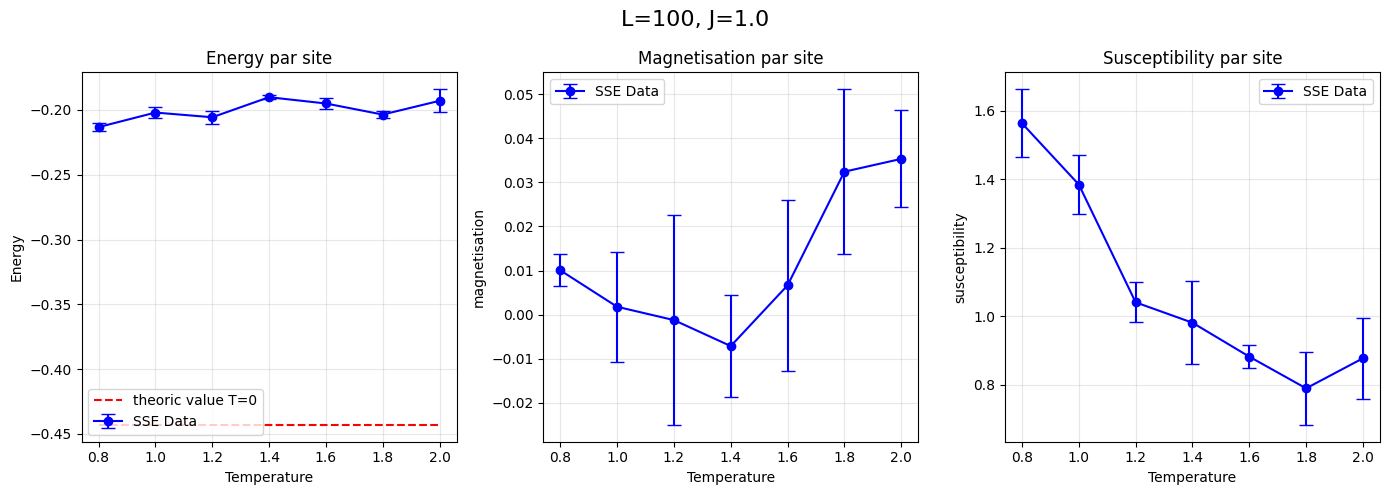

In [ ]:
E0_theoric = -0.4431

x_min = min(temp_list)
x_max = max(temp_list)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

ax1.errorbar(temp_list, e_list, yerr=e_error, fmt='o-',
              color='blue', capsize=5, label='SSE Data')
ax1.hlines(E0_theoric, x_min,  x_max, linestyle='--', color='red', label='theoric value T=0')
ax1.set_title(f"Energy par site")
ax1.set_xlabel("Temperature")
ax1.set_ylabel("Energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.errorbar(temp_list, m_list, yerr=m_error, fmt='o-',
              color='blue', capsize=5, label='SSE Data')
#ax2.hlines(m_theoric, x_min,  x_max, linestyle='--', color='red', label='theoric value')
ax2.set_title(f"Magnetisation par site")
ax2.set_xlabel("Temperature")
ax2.set_ylabel("magnetisation")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.errorbar(temp_list, susceptibility_list, yerr=s_error, fmt='o-',
              color='blue', capsize=5, label='SSE Data')
#ax3.hlines(susceptibility_theoric, x_min,  x_max, linestyle='--', color='red', label='theoric value')
ax3.set_title(f"Susceptibility par site")
ax3.set_xlabel("Temperature")
ax3.set_ylabel("susceptibility")
ax3.legend()
ax3.grid(True, alpha=0.3)

fig.suptitle(f"L={L}, J={J}", fontsize=16)
plt.tight_layout()
plt.show()